# Commonwealth Wind Working Analysis

This analysis notebook should be considered under construction while assumptions are brought up to date, and the model is refined

## Imports and Setup

In [1]:
from pathlib import Path
from itertools import product

import pandas as pd
import matplotlib.pyplot as plt

from whale import Project
from whale.utilities import load_yaml

pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_columns = 100
pd.options.display.max_rows = 1000

%load_ext autoreload
%autoreload 2

### Project List and General Definitions


#### TODO
- Update weather profiles

In [2]:
project_name = "Commonwealth"
library_path = Path("library").resolve()

In [3]:
metrics_configuration = {
    "# Turbines": {"metric": "n_turbines", "kwargs": {}},
    "Turbine Rating (MW)": {"metric": "turbine_rating", "kwargs": {}},
    "Project Capacity (MW)": {"metric": "capacity", "kwargs": {"units": "mw"}},
    "# OSS": {"metric": "n_substations", "kwargs": {}},
    "Total Export Cable Length (km)": {"metric": "export_system_total_cable_length", "kwargs": {}},
    "Total Array Cable Length (km)": {"metric": "array_system_total_cable_length", "kwargs": {}},
    "CapEx ($)": {"metric": "capex", "kwargs": {}},
    "CapEx per kW ($/kW)": {"metric": "capex", "kwargs": {"per_capacity": "kw"}},
    "OpEx ($)": {"metric": "opex", "kwargs": {}},
    "OpEx per kW ($/kW)": {"metric": "opex", "kwargs": {"per_capacity": "kw"}},
    "AEP (MWh)": {
        "metric": "energy_production",
        "kwargs": {"units": "mw", "aep": True, "with_losses": True}
    },
    "AEP per kW (MWh/kW)": {
        "metric": "energy_production",
        "kwargs": {"units": "mw", "per_capacity": "kw", "aep": True, "with_losses": True}
    },
    "Net Capacity Factor Without Unmodeled Losses (%)": {
        "metric": "capacity_factor",
        "kwargs": {"which": "net"}
    },
    "Net Capacity Factor With All Losses (%)": {
        "metric": "capacity_factor",
        "kwargs": {"which": "net", "with_losses": True}
    },
    "Gross Capacity Factor (%)": {"metric": "capacity_factor", "kwargs": {"which": "gross"}},
    "Energy Availability (%)": {"metric": "availability", "kwargs": {"which": "energy"}},
    "LCOE ($/MWh)": {"metric": "lcoe", "kwargs": {}},
    "IRR (%)": {"metric": "irr", "kwargs": {}},
    "NPV ($)": {"metric": "npv", "kwargs": {}},
}

metrics_order = [
    "# Turbines",
    "Turbine Rating (MW)",
    "Project Capacity (MW)",
    "# OSS",
    "Total Export Cable Length (km)",
    "Total Array Cable Length (km)",
    "FCR (%)",
    "Offtake Price ($/MWh)",
    "CapEx ($)",
    "CapEx per kW ($/kW)",
    "System CapEx for Export Cables ($)",
    "Installation CapEx for Export Cables ($)",
    "CapEx Without Export Cables ($)",
    "OpEx ($)",
    "OpEx per kW ($/kW)",
    "Annual OpEx per kW ($/kW)",
    "Energy Availability (%)",
    "Gross Capacity Factor (%)",
    "Net Capacity Factor Without Unmodeled Losses (%)",
    "Net Capacity Factor With All Losses (%)",
    "AEP (MWh)",
    "AEP per kW (MWh/kW)",
    "LCOE ($/MWh)",
    "IRR (%)",
    "NPV ($)",
]
final_cols = ["CapEx ($)", "OpEx ($)", "Energy Production (GWh)", "Revenue ($)", "Cash Flow ($)"]

ORBIT library intialized at '/Users/rhammond/Documents/GitHub/WHaLE/examples/library'


Missing data in columns ['bury_speed']; all values will be calculated.

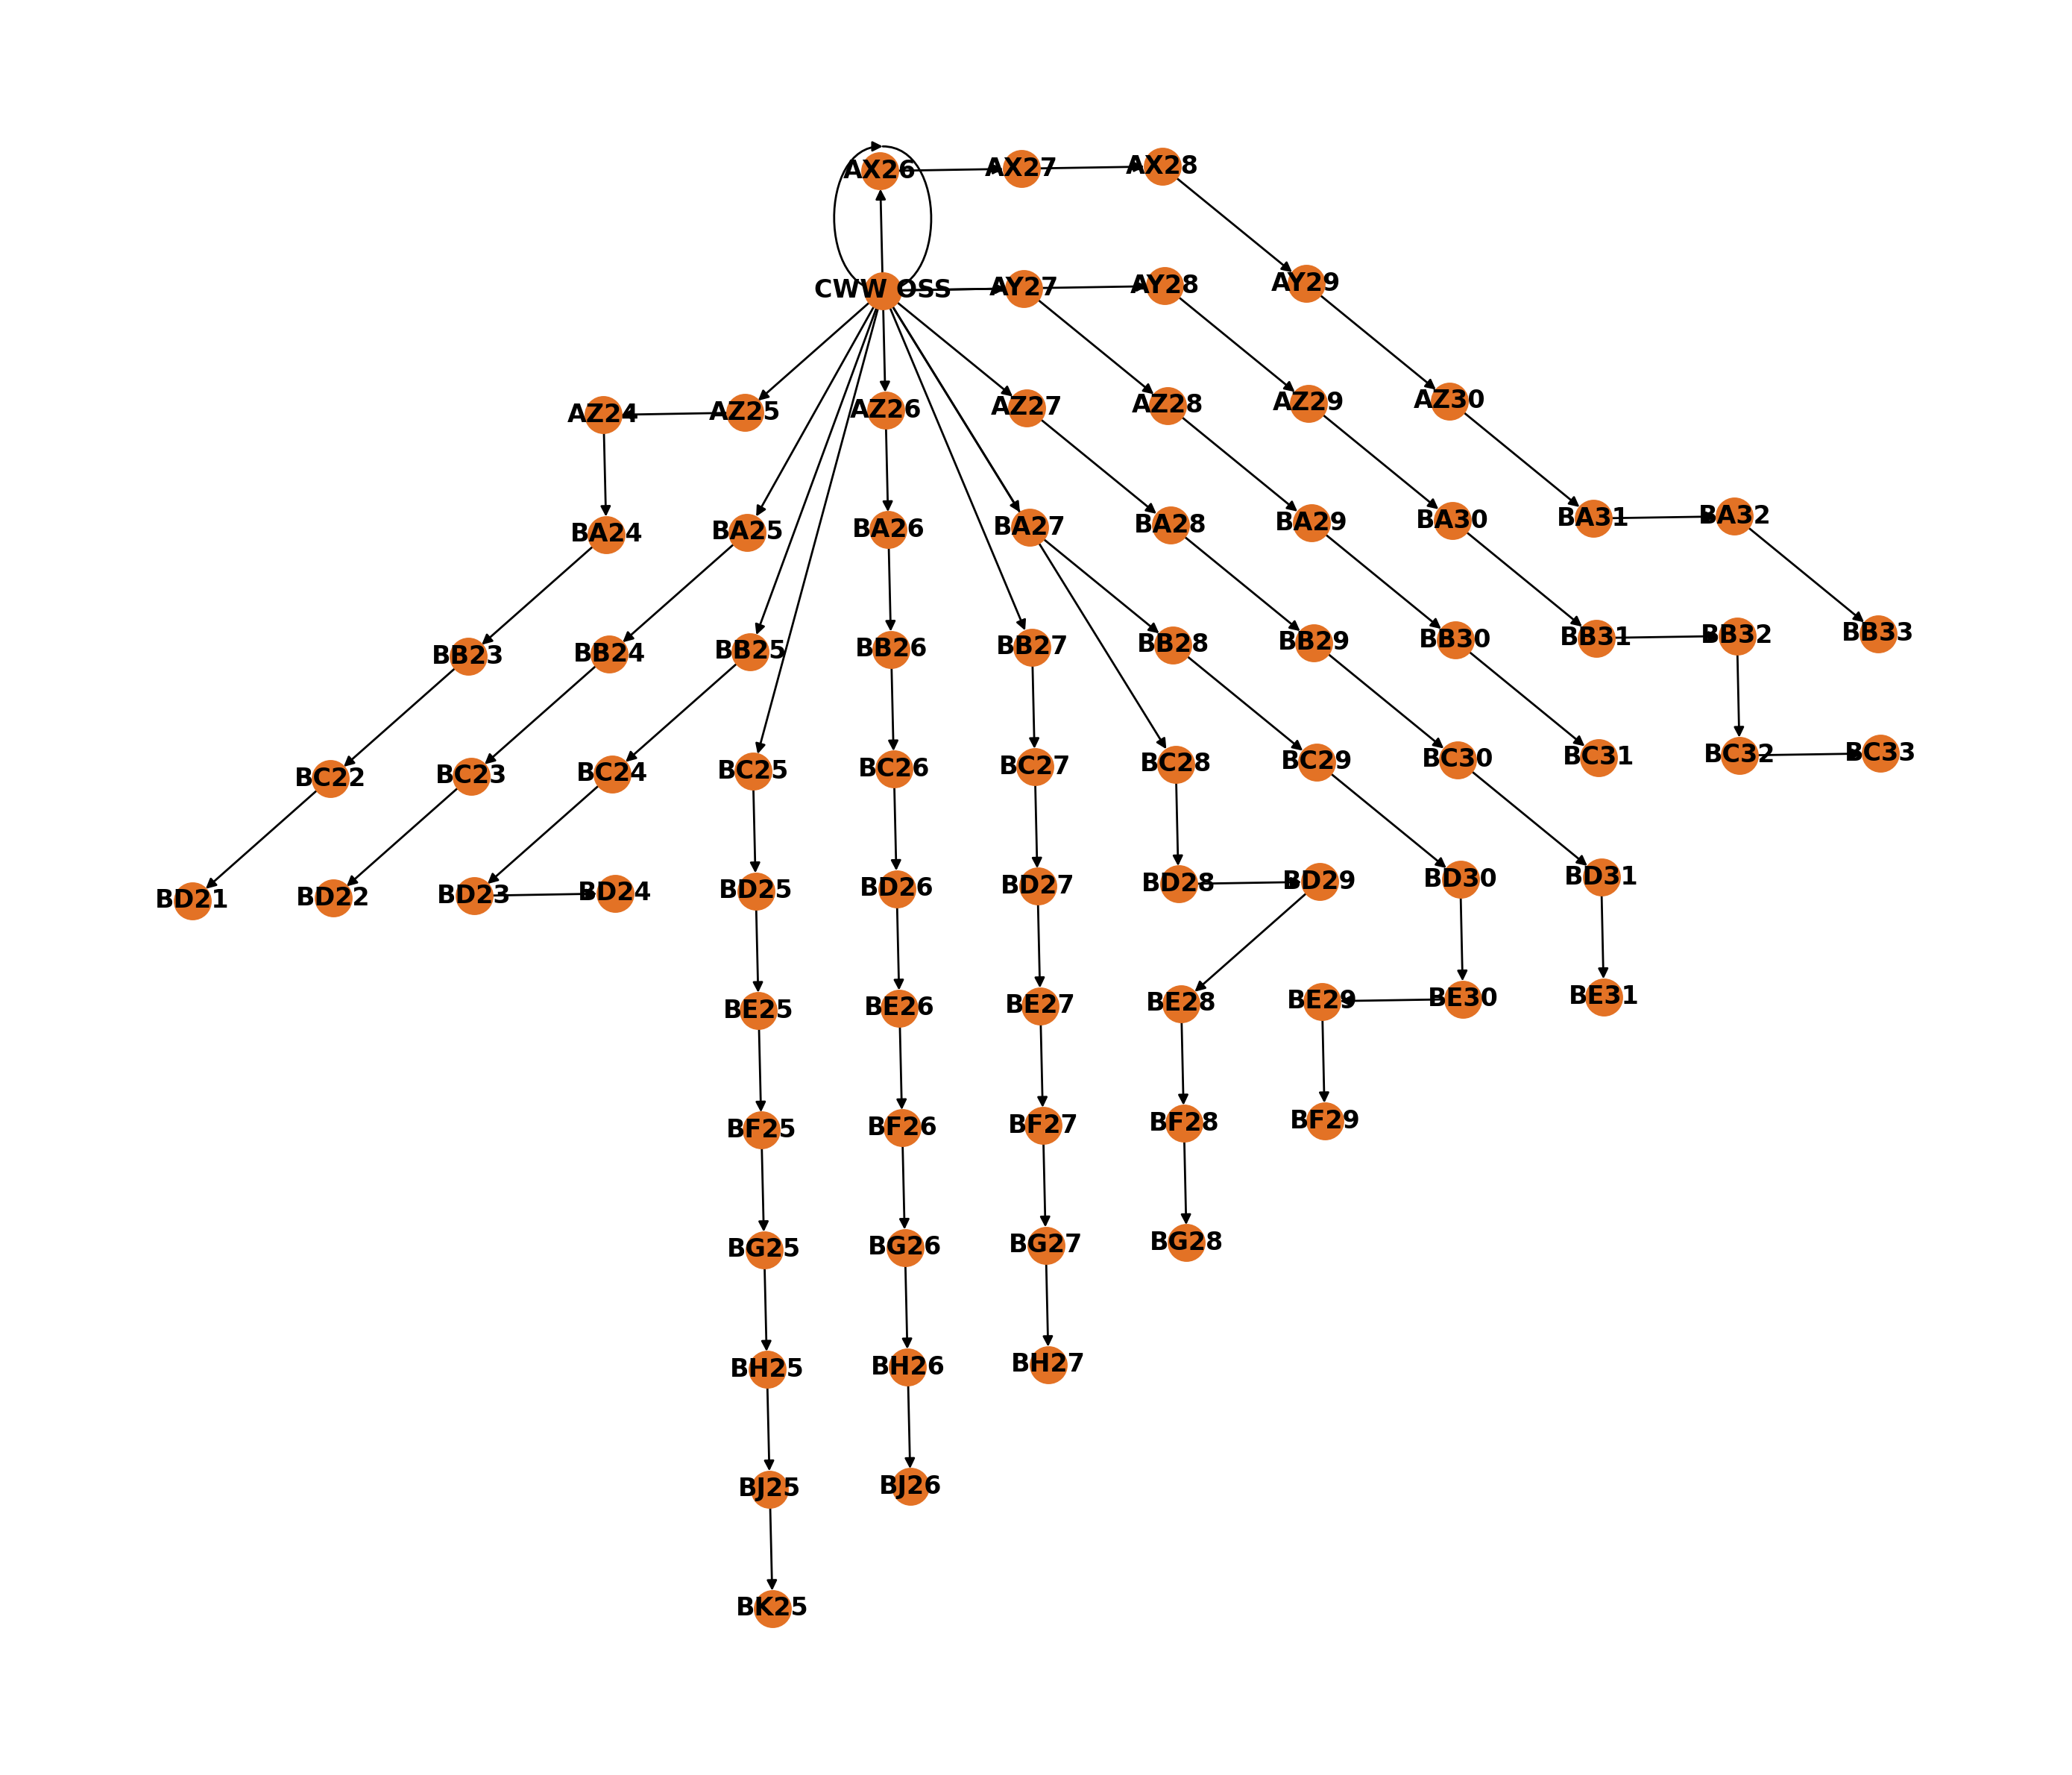

In [4]:
config = load_yaml(
    library_path / "project/config",
    f"{project_name.replace(' ', '_')}_base.yaml"
)
project = Project(
    # Basic Model Configurations
    library_path=library_path,
    weather_profile=library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023.csv",
    connect_floris_to_layout=True,
    connect_orbit_array_design=True,
    **config,
)

# Plot the layout and save the figures
fig, ax = project.plot_farm(return_fig=True)
# fig.savefig(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_layout.svg")

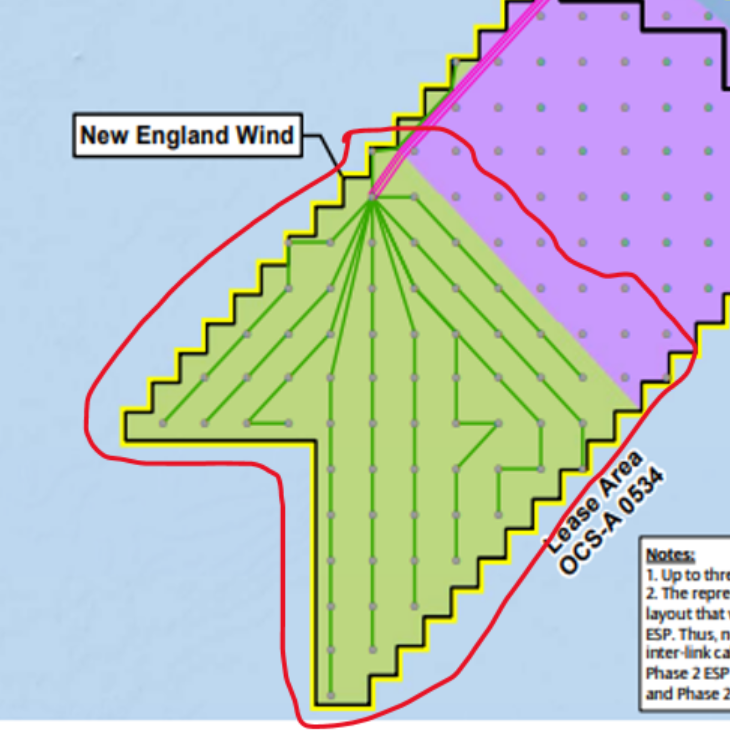

## Run the analyses and calculate results

This separately calls the `run` methods for each of the ORBIT `ProjectManager` and WOMBAT `Simualation`, in that order. Alternatively, these could just be called on their own, just like we must with FLORIS for the time being.

**NOTE: Array Cable installation is commented out in the configuration for a `StateExhausted` error I can't figure out.**

In [5]:
# Run the project and clean up the logging
project.run(
    which_floris="wind_rose",
    full_wind_rose=False,
    floris_reinitialize_kwargs=dict(cut_in_wind_speed=3.0, cut_out_wind_speed=25.0)
)
project.wombat.env.cleanup_log_files()  # Delete logging data from WOMBAT

Missing data in columns ['bury_speed']; all values will be calculated.

Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5


In [6]:
# Gather the high-level results
report_df = project.generate_report(metrics_configuration, project_name).T
export_system = project.orbit.system_costs["ExportCableInstallation"]
export_installation = project.orbit.installation_costs["ExportCableInstallation"]
capex_sans_export = project.orbit.total_capex - export_system - export_installation
additional_reporting = pd.DataFrame(
    [
        ["FCR (%)", project.fixed_charge_rate],
        ["Offtake Price ($/MWh)", project.offtake_price],
        ["System CapEx for Export Cables ($)", export_system],
        ["Installation CapEx for Export Cables ($)", export_installation],
        ["CapEx Without Export Cables ($)", capex_sans_export],
        ["Annual OpEx per kW ($/kW)", report_df.loc["OpEx per kW ($/kW)", project_name] / project.operations_years],
    ],
    columns=["Project"] + report_df.columns.tolist(),
).set_index("Project")
report_df = pd.concat((report_df, additional_reporting), axis=0).loc[metrics_order]

# Gather the detailed results
monthly_results = project.cash_flow(breakdown=True).join(project.energy_production(frequency="month-year")).fillna(0)
monthly_results = monthly_results.assign(
    CapEx_Installation=monthly_results[[c for c in monthly_results if c.startswith("CapEx") and c.endswith("Installation")]].sum(axis=1),
    CapEx_System=monthly_results[[c for c in monthly_results if c.startswith("CapEx") and c.endswith("System")]].sum(axis=1),
)

# monthly_results.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_monthly_detailed_results.csv")

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.FutureWarning: /Users/rhammond/Documents/GitHub/develop_installs/WOMBAT/wombat/core/post_processor.py:1327
The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.FutureWarning: /Users/rhammond/Documents/GitHub/develop_installs/WOMBAT/wombat/core/post_processor.py:1327
The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.

In [7]:
monthly_results["CapEx ($)"] = monthly_results[["CapEx_Installation", "CapEx_Soft", "CapEx_Project", "CapEx_System", "CapEx_Turbine"]].sum(axis=1)
monthly_results = monthly_results.rename(columns={"OpEx": "OpEx ($)","Revenue": "Revenue ($)", "cash_flow": "Cash Flow ($)"})[final_cols]

# Create the inputs data
inputs = pd.DataFrame(
    [
        ["FCR", project.fixed_charge_rate],
        ["Offtake price ($/MWh)", project.offtake_price],
        ["Lease Area Price ($)", project.orbit.config["project_parameters"]["site_auction_price"]],
        ["Discount rate (%)", project.discount_rate],
        ["# Turbines", project.n_turbines()],
        ["Turbine Rating (MW)", project.turbine_rating()],
        ["Project Capacity (MW)", project.capacity("mw")],
        ["# OSS", project.n_substations()],
        ["Substructure type", "??"],
        ["Row spacing (rotor diameters)", "not used for custom layouts"],
        ["Turbine spacing (rotor diameters)", "not used for custom layouts"],
        ["Depth (m)", project.orbit.config["site"]["depth"]],
        [
            "Mean wind speed (m/s)",
            project.weather.loc[
                project.orbit_start_date: project.wombat.env.end_datetime,
                "windspeed_100m"
            ].mean()
        ],
        ["Distance to landfall (km)", project.orbit.config["site"]["distance_to_landfall"]],
        ["Distance to port (km)", project.wombat.config.port_distance],
        ["Interconnection distance (km)", project.orbit._phases["ExportSystemDesign"]._distance_to_interconnection],
        ["# of POIs", "??"],
        ["Export cable type", [*project.orbit._phases["ExportSystemDesign"].cable_lengths_by_type]],
        ["Array cable type", [*project.orbit._phases["CustomArraySystemDesign"].cable_lengths_by_type]],
    ],
    columns=["Inputs", f"{project_name}"]
).set_index("Inputs")

# Save the outputs
report_df.index.name = "Metrics"

## Results

In [8]:
# report_df.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_metrics.csv")
# inputs.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_inputs.csv")
# monthly_results.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_monthly_results.csv")

In [9]:
report_df

,Commonwealth
Metrics,
# Turbines,78.0000
Turbine Rating (MW),16.0000
Project Capacity (MW),"1,248.0000"
# OSS,2.0000
Total Export Cable Length (km),440.2044
Total Array Cable Length (km),201.3542
FCR (%),0.0582
Offtake Price ($/MWh),72.0000
CapEx ($),"4,464,042,237.6212"


In [11]:
monthly_results

CapEx ($)         OpEx ($)  Energy Production (GWh)  \
year month                                                               
1995 1     -677,863,680.0000          -0.0000                   0.0000   
     2                0.0000           0.0000                   0.0000   
     3                0.0000           0.0000                   0.0000   
     4                0.0000           0.0000                   0.0000   
     5                0.0000           0.0000                   0.0000   
     6                0.0000           0.0000                   0.0000   
     7                0.0000           0.0000                   0.0000   
     8                0.0000           0.0000                   0.0000   
     9                0.0000           0.0000                   0.0000   
     10               0.0000           0.0000                   0.0000   
     11               0.0000           0.0000                   0.0000   
     12               0.0000           0.0000                   0.0000   
1996 1     -217,692,560.3587          -0.0000                   0.0000   
     2                0.0000           0.0000                   0.0000   
     3                0.0000           0.0000                   0.0000   
     4     -204,834,476.3587          -0.0000                   0.0000   
     5                0.0000           0.0000                   0.0000   
     6                0.0000           0.0000                   0.0000   
     7     -217,692,560.3587          -0.0000                   0.0000   
     8                0.0000           0.0000                   0.0000   
     9                0.0000           0.0000                   0.0000   
     10    -204,834,476.3587          -0.0000                   0.0000   
     11               0.0000           0.0000                   0.0000   
     12               0.0000           0.0000                   0.0000   
1997 1     -217,692,560.3587          -0.0000                   0.0000   
     2                0.0000           0.0000                   0.0000   
     3                0.0000           0.0000                   0.0000   
     4     -204,834,476.3587          -0.0000                   0.0000   
     5                0.0000           0.0000                   0.0000   
     6                0.0000           0.0000                   0.0000   
     7     -217,692,560.3587          -0.0000                   0.0000   
     8                0.0000           0.0000                   0.0000   
     9                0.0000           0.0000                   0.0000   
     10    -204,834,476.3587          -0.0000                   0.0000   
     11               0.0000           0.0000                   0.0000   
     12               0.0000           0.0000                   0.0000   
1998 1     -451,543,657.1390          -0.0000                   0.0000   
     2      -15,481,915.0156          -0.0000                   0.0000   
     3      -17,053,155.1729          -0.0000                   0.0000   
     4     -230,748,114.7995          -0.0000                   0.0000   
     5      -28,290,136.6685          -0.0000                   0.0000   
     6      -25,935,139.3659          -0.0000                   0.0000   
     7     -228,109,581.4217          -0.0000                   0.0000   
     8      -20,988,659.9439          -0.0000                   0.0000   
     9      -20,320,936.7458          -0.0000                   0.0000   
     10    -218,924,012.2637          -0.0000                   0.0000   
     11      -7,356,717.7397          -0.0000                   0.0000   
     12      -7,632,471.1644          -0.0000                   0.0000   
1999 1     -209,182,484.2354          -0.0000                   0.0000   
     2                0.0000           0.0000                   0.0000   
     3                0.0000           0.0000                   0.0000   
     4     -204,834,476.3587          -0.0000                   0.0000   
     5                0